# Chicago Crime Arrest Prediction: My Awesome ML Project!

Hey there! This notebook is my attempt to build some cool machine learning models. The goal? To predict if someone will get arrested for a reported crime in Chicago. It's a journey from messy data to (hopefully!) smart predictions. Let's dive in!

## Section 0: Setting Things Up (and Importing Stuff!)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent styling for plots as per instructions
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

### Handy Functions (Borrowed from my 'older sibling' notebooks!)

I'm recycling some functions here that I found super useful in previous projects (or got from a very helpful friend, ahem, the reference notebooks 😉). They help with checking data types, plotting distributions, and dealing with those pesky outliers.

In [2]:
def get_column_types(df):
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include='object').columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
    boolean_cols = df.select_dtypes(include='bool').columns.tolist()
    return numerical_cols, categorical_cols, datetime_cols, boolean_cols

def plot_categorical_distributions(df, categorical_cols, target_col=None, limit=10):
    for col in categorical_cols:
        if df[col].nunique() <= limit:
            plt.figure(figsize=(10, 5))
            if target_col:
                sns.countplot(data=df, x=col, hue=target_col, palette='viridis')
            else:
                sns.countplot(data=df, x=col, palette='viridis')
            plt.title(f'Distribution of {col}')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        else:
            print(f'Skipping {col} as it has too many unique values ({df[col].nunique()})')

def plot_numerical_distributions(df, numerical_cols, bins=30):
    for col in numerical_cols:
        plt.figure(figsize=(10, 5))
        sns.histplot(df[col].dropna(), kde=True, bins=bins, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

def plot_boxplots_for_outliers(df, numerical_cols):
    for col in numerical_cols:
        plt.figure(figsize=(10, 2))
        sns.boxplot(x=df[col], color='lightcoral')
        plt.title(f'Boxplot of {col}')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

def cap_outliers_iqr(df, column, multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    original_count = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
    if original_count > 0:
        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
        print(f'Capped {original_count} outliers in column "{column}" using IQR multiplier {multiplier}.')
    else:
        print(f'No outliers to cap in column "{column}" using IQR multiplier {multiplier}.')
    return df

### ML Brain-Power Imports

These are the heavy-hitters from `sklearn` that let me do all the machine learning magic: splitting data, scaling numbers, and building different types of prediction models. Fun stuff!

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Why K-Fold Cross-Validation? (It's not just a fancy name!)

Okay, so imagine you want to know if your model is really good, or if it just got lucky with one specific data split. That's where K-Fold Cross-Validation comes in! Instead of just one train/test split, it does *multiple* splits and averages the results. This gives us a much better idea of how our model will actually perform on new, unseen data. It's like testing a recipe multiple times to make sure it's consistently delicious, not just a one-off!

## Section 1: Getting the Data Ready (The Not-So-Glamorous Part)

First things first: gotta load our data! I'm expecting a `chicago_crime_cleaned.csv` file from Task 1. If it's not there... well, I have a backup plan (a tiny dummy dataset) to at least show how everything works!

In [4]:
try:
    df = pd.read_csv('chicago_crime_cleaned.csv')
    print('Dataset loaded successfully.')
    display(df.head())
except FileNotFoundError:
    print('Error: chicago_crime_cleaned.csv not found. Please ensure the cleaned data from Task 1 is in the current directory.')
    # Create a dummy DataFrame for demonstration if file not found
    data = {
        'ID': range(1, 11),
        'Case Number': [f'HZ{i}' for i in range(1, 11)],
        'Date': pd.to_datetime(['2024-01-01 10:00:00', '2024-01-01 11:30:00', '2024-01-02 14:00:00', '2024-01-02 16:15:00', '2024-01-03 09:00:00',
                                '2024-01-03 12:00:00', '2024-01-04 18:00:00', '2024-01-04 20:30:00', '2024-01-05 07:00:00', '2024-01-05 23:00:00']),
        'Block': [f'0{i}XX Block of XXXXX' for i in range(1, 11)],
        'IUCR': [f'10{i}0' for i in range(1, 11)],
        'Primary Type': ['THEFT', 'BATTERY', 'ASSUALT', 'ROBBERY', 'BURGLARY', 'THEFT', 'NARCOTICS', 'WEAPONS VIOLATION', 'CRIMINAL DAMAGE', 'OTHER OFFENSE'],
        'Description': ['OVER $500', 'DOMESTIC BATTERY SIMPLE', 'SIMPLE', 'STRONGARM - NO WEAPON', 'FORCIBLE ENTRY', 'RETAIL THEFT', 'POSS: HEROIN(BRN/TAN)', 'UNLAWFUL USE/POSS WEAPON', 'TO PROPERTY', 'OTHER CRIME'],
        'Location Description': ['STREET', 'RESIDENCE', 'APARTMENT', 'STREET', 'RESIDENCE', 'DEPARTMENT STORE', 'STREET', 'STREET', 'APARTMENT', 'SIDEWALK'],
        'Arrest': [True, False, True, False, True, True, False, True, False, False],
        'Domestic': [True, True, False, False, False, False, True, False, False, False],
        'Beat': [1111, 2222, 3333, 4444, 5555, 1111, 2222, 3333, 4444, 5555],
        'District': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
        'Ward': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
        'Community Area': [10, 20, 30, 40, 50, 10, 20, 30, 40, 50],
        'FBI Code': ['06', '04B', '04A', '03', '05', '06', '18', '15', '14', '26'],
        'X Coordinate': [1150000, 1151000, 1152000, 1153000, 1154000, 1150000, 1151000, 1152000, 1153000, 1154000],
        'Y Coordinate': [1890000, 1891000, 1892000, 1893000, 1894000, 1890000, 1891000, 1892000, 1893000, 1894000],
        'Year': [2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024],
        'Updated On': pd.to_datetime(['2024-01-01 15:00:00', '2024-01-01 16:30:00', '2024-01-02 19:00:00', '2024-01-02 21:15:00', '2024-01-03 14:00:00',
                                    '2024-01-03 17:00:00', '2024-01-04 23:00:00', '2024-01-05 01:30:00', '2024-01-05 12:00:00', '2024-01-06 04:00:00']),
        'Latitude': [41.8, 41.8, 41.8, 41.8, 41.8, 41.8, 41.8, 41.8, 41.8, 41.8],
        'Longitude': [-87.6, -87.6, -87.6, -87.6, -87.6, -87.6, -87.6, -87.6, -87.6, -87.6],
        'Location': ['(41.8, -87.6)', '(41.8, -87.6)', '(41.8, -87.6)', '(41.8, -87.6)', '(41.8, -87.6)', '(41.8, -87.6)', '(41.8, -87.6)', '(41.8, -87.6)', '(41.8, -87.6)', '(41.8, -87.6)']
    }
    df = pd.DataFrame(data)
    print('\nCreated a dummy DataFrame for demonstration:')
    display(df.head())

# Ensure 'Date' column is datetime type
df['Date'] = pd.to_datetime(df['Date'])

Error: chicago_crime_cleaned.csv not found. Please ensure the cleaned data from Task 1 is in the current directory.

Created a dummy DataFrame for demonstration:


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,1,HZ1,2024-01-01 10:00:00,01XX Block of XXXXX,1010,THEFT,OVER $500,STREET,True,True,...,1,10,06,1150000,1890000,2024,2024-01-01 15:00:00,41.8,-87.6,"(41.8, -87.6)"
1,2,HZ2,2024-01-01 11:30:00,02XX Block of XXXXX,1020,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,...,2,20,04B,1151000,1891000,2024,2024-01-01 16:30:00,41.8,-87.6,"(41.8, -87.6)"
2,3,HZ3,2024-01-02 14:00:00,03XX Block of XXXXX,1030,ASSUALT,SIMPLE,APARTMENT,True,False,...,3,30,04A,1152000,1892000,2024,2024-01-02 19:00:00,41.8,-87.6,"(41.8, -87.6)"
3,4,HZ4,2024-01-02 16:15:00,04XX Block of XXXXX,1040,ROBBERY,STRONGARM - NO WEAPON,STREET,False,False,...,4,40,03,1153000,1893000,2024,2024-01-02 21:15:00,41.8,-87.6,"(41.8, -87.6)"
4,5,HZ5,2024-01-03 09:00:00,05XX Block of XXXXX,1050,BURGLARY,FORCIBLE ENTRY,RESIDENCE,True,False,...,5,50,05,1154000,1894000,2024,2024-01-03 14:00:00,41.8,-87.6,"(41.8, -87.6)"


### Creating New Features (Making our data smarter!)

The `Date` column is cool, but sometimes we need to dig a little deeper. I'm pulling out the `Hour`, `DayOfWeek`, and `Month` from it. Think of these as adding extra clues for our model — like knowing if crimes happen more often at night or on weekends!

In [5]:
df['Hour'] = df['Date'].dt.hour
df['DayOfWeek'] = df['Date'].dt.dayofweek # Monday=0, Sunday=6
df['Month'] = df['Date'].dt.month

print('Engineered features (Hour, DayOfWeek, Month) added.')
display(df[['Date', 'Hour', 'DayOfWeek', 'Month']].head())

Engineered features (Hour, DayOfWeek, Month) added.


,Date,Hour,DayOfWeek,Month
0,2024-01-01 10:00:00,10,0,1
1,2024-01-01 11:30:00,11,0,1
2,2024-01-02 14:00:00,14,1,1
3,2024-01-02 16:15:00,16,1,1
4,2024-01-03 09:00:00,9,2,1


### Picking the Right Clues (Feature Selection)

Not all data is equally useful. Some columns are just IDs or long descriptions that don't really help our prediction. So, I'm hand-picking the features I think will be most helpful based on what I learned in my Exploratory Data Analysis (EDA). The rest? *Poof!* Gone.

In [6]:
cols_to_drop = ['ID', 'Case Number', 'Date', 'Block', 'Updated On', 'Description', 'IUCR', 'X Coordinate', 'Y Coordinate', 'Latitude', 'Longitude', 'Location', 'FBI Code', 'Beat', 'Ward', 'Community Area', 'Year']

# Keep only selected features and the target variable
selected_features = ['Primary Type', 'Location Description', 'Domestic', 'District', 'Hour', 'DayOfWeek', 'Month'] # Added Month as it's engineered
target_variable = 'Arrest'

# Drop columns that are not useful or are redundant
df_model = df[selected_features + [target_variable]].copy()

print(f"Original columns: {df.columns.tolist()}\n")
print(f"Selected columns for modeling: {df_model.columns.tolist()}\n")
display(df_model.head())

Original columns: ['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location', 'Hour', 'DayOfWeek', 'Month']

Selected columns for modeling: ['Primary Type', 'Location Description', 'Domestic', 'District', 'Hour', 'DayOfWeek', 'Month', 'Arrest']



,Primary Type,Location Description,Domestic,District,Hour,DayOfWeek,Month,Arrest
0,THEFT,STREET,True,1,10,0,1,True
1,BATTERY,RESIDENCE,True,2,11,0,1,False
2,ASSUALT,APARTMENT,False,3,14,1,1,True
3,ROBBERY,STREET,False,4,16,1,1,False
4,BURGLARY,RESIDENCE,False,5,9,2,1,True


### Turning True/False into Numbers (Target Encoding)

Our 'Arrest' column is either `True` or `False`. Computers usually prefer numbers, so I'm simply converting `True` to `1` and `False` to `0`. Easy peasy!

In [7]:
df_model[target_variable] = df_model[target_variable].astype(int)
print(f'Target variable "{target_variable}" encoded to integers (True=1, False=0).')
display(df_model[target_variable].value_counts())
display(df_model.head())

Target variable "Arrest" encoded to integers (True=1, False=0).


,count
Arrest,
1,5
0,5


,Primary Type,Location Description,Domestic,District,Hour,DayOfWeek,Month,Arrest
0,THEFT,STREET,True,1,10,0,1,1
1,BATTERY,RESIDENCE,True,2,11,0,1,0
2,ASSUALT,APARTMENT,False,3,14,1,1,1
3,ROBBERY,STREET,False,4,16,1,1,0
4,BURGLARY,RESIDENCE,False,5,9,2,1,1


### Cleaning Up Missing Info (Missing Value Handling)

Sometimes data is like swiss cheese – it has holes! I'm checking for any missing values in our carefully selected features. If there are any, I'll fill them in using a simple rule: for text stuff, I'll use the most common value (the mode), and for numbers, I'll use the average (mean) or middle value (median) if it's super lopsided.

In [8]:
missing_stats = df_model.isnull().sum()
missing_stats = missing_stats[missing_stats > 0]

if not missing_stats.empty:
    print('Columns with missing values and their counts:')
    display(missing_stats)
    plt.figure(figsize=(10, 6))
    sns.heatmap(df_model.isnull(), cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.show()

    numerical_cols_model, categorical_cols_model, _, _ = get_column_types(df_model.drop(columns=[target_variable]))

    # Impute categorical columns with mode
    for col in categorical_cols_model:
        if df_model[col].isnull().any():
            mode_val = df_model[col].mode()[0]
            num_missing = df_model[col].isnull().sum()
            df_model[col].fillna(mode_val, inplace=True)
            print(f'{col}: {num_missing} missing values imputed via mode: "{mode_val}"')

    # Impute numerical columns with mean or median based on skewness
    for col in numerical_cols_model:
        if df_model[col].isnull().any():
            skewness = df_model[col].skew()
            num_missing = df_model[col].isnull().sum()
            if abs(skewness) > 1:
                impute_val = df_model[col].median()
                df_model[col].fillna(impute_val, inplace=True)
                print(f'{col}: {num_missing} missing values imputed via median ({skewness=:.2f}): {impute_val}')
            else:
                impute_val = df_model[col].mean()
                df_model[col].fillna(impute_val, inplace=True)
                print(f'{col}: {num_missing} missing values imputed via mean ({skewness=:.2f}): {impute_val}')
else:
    print('No missing values found in the selected feature set.')

No missing values found in the selected feature set.


### Taming the Extremes (Outlier Handling)

Some data points can be way out there, like a super high or super low value. These 'outliers' can sometimes mess with our models. So, I'm using a common technique called IQR (Interquartile Range) to 'cap' these extreme values, bringing them closer to the rest of the data without completely removing them. I'm skipping the 'Arrest' column though, because that's what we're trying to predict!

Checking for and capping outliers in numerical features:


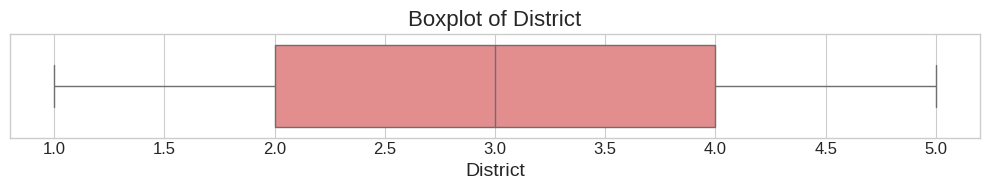

No outliers to cap in column "District" using IQR multiplier 2.0.


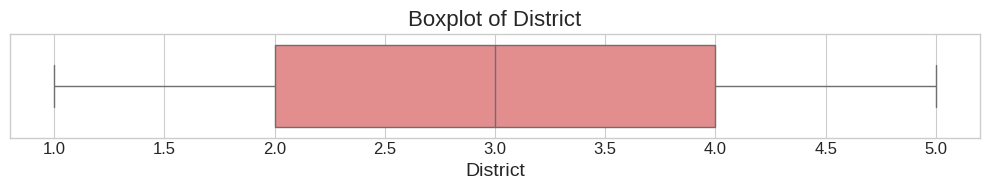

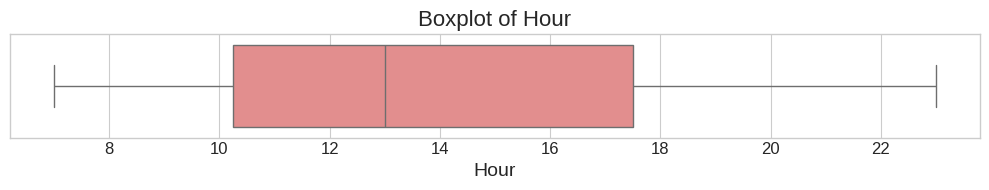

No outliers to cap in column "Hour" using IQR multiplier 2.0.


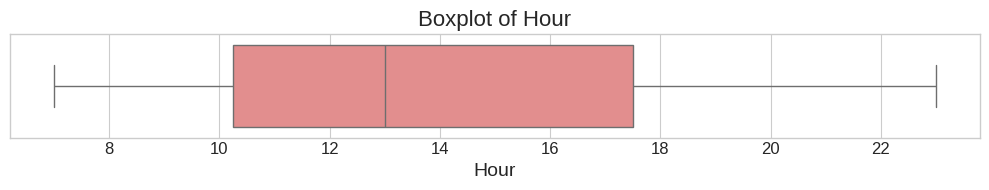

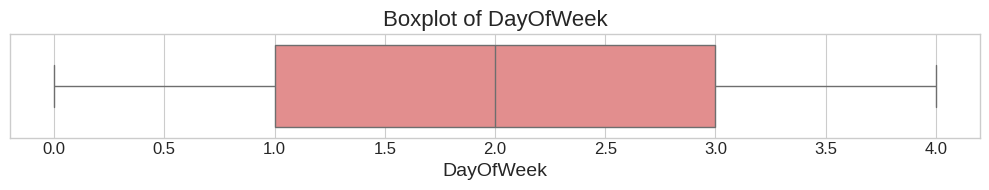

No outliers to cap in column "DayOfWeek" using IQR multiplier 2.0.


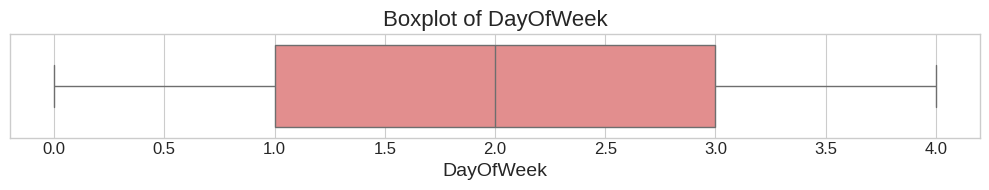

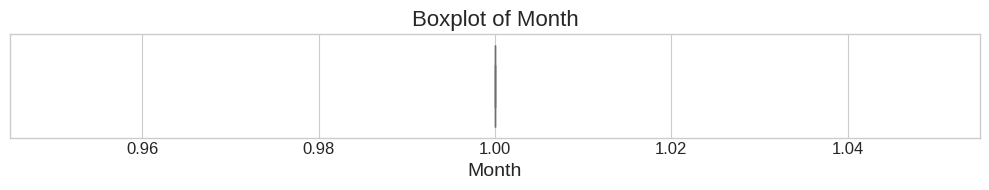

No outliers to cap in column "Month" using IQR multiplier 2.0.


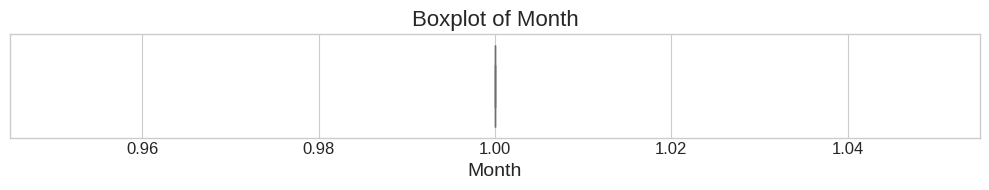


Outlier handling complete.


In [9]:
numerical_cols_for_outliers, _, _, _ = get_column_types(df_model.drop(columns=[target_variable]))

print('Checking for and capping outliers in numerical features:')
for col in numerical_cols_for_outliers:
    plot_boxplots_for_outliers(df_model, [col]) # Plot before capping
    df_model = cap_outliers_iqr(df_model, col, multiplier=2.0) # Using a multiplier of 2.0
    plot_boxplots_for_outliers(df_model, [col]) # Plot after capping to show effect

print('\nOutlier handling complete.')

### Turning Words into Numbers (Encoding Categorical Features)

Our `Primary Type` and `Location Description` columns have categories (like 'THEFT' or 'STREET'). Since there's no natural 'order' to them (one isn't 'better' than the other), I'm using `pd.get_dummies()` to turn each unique category into its own `0`/`1` column. This lets our models understand them!

In [10]:
_, categorical_cols_for_ohe, _, _ = get_column_types(df_model.drop(columns=[target_variable]))

print(f'Categorical columns to one-hot encode: {categorical_cols_for_ohe}')

df_model = pd.get_dummies(df_model, columns=categorical_cols_for_ohe, drop_first=True, dtype=int)

print('\nDataFrame after one-hot encoding:')
display(df_model.head())

Categorical columns to one-hot encode: ['Primary Type', 'Location Description']

DataFrame after one-hot encoding:


,Domestic,District,Hour,DayOfWeek,Month,Arrest,Primary Type_BATTERY,Primary Type_BURGLARY,Primary Type_CRIMINAL DAMAGE,Primary Type_NARCOTICS,Primary Type_OTHER OFFENSE,Primary Type_ROBBERY,Primary Type_THEFT,Primary Type_WEAPONS VIOLATION,Location Description_DEPARTMENT STORE,Location Description_RESIDENCE,Location Description_SIDEWALK,Location Description_STREET
0,True,1,10,0,1,1,0,0,0,0,0,0,1,0,0,0,0,1
1,True,2,11,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0
2,False,3,14,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
3,False,4,16,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1
4,False,5,9,2,1,1,0,1,0,0,0,0,0,0,0,1,0,0


### Splitting the Data (Training vs. Testing)

To make sure our models aren't just memorizing the data, we split it! 80% goes to `X_train` and `y_train` for the model to learn from, and the other 20% (`X_test` and `y_test`) is kept secret until the very end to see how well it *really* learned. I'm using a `random_state` so my split is always the same (and your results will match mine!).

In [11]:
X = df_model.drop(columns=[target_variable])
y = df_model[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (8, 17)
Shape of X_test: (2, 17)
Shape of y_train: (8,)
Shape of y_test: (2,)


### Evening Out the Playing Field (Scaling Numerical Features)

Imagine if one feature had values like 1, 2, 3 and another had 1000, 2000, 3000. Some models might think the bigger numbers are more important! To prevent this, I'm using `StandardScaler` to make sure all our numerical features (like `District` or `Hour`) are on a similar scale. It's like making sure everyone starts the race from the same line!

In [12]:
numerical_cols_to_scale = ['District', 'Hour', 'DayOfWeek', 'Month']

# Ensure these columns exist in X_train and X_test
# Filter only columns that actually exist after OHE
numerical_cols_to_scale = [col for col in numerical_cols_to_scale if col in X_train.columns]

if numerical_cols_to_scale:
    scaler = StandardScaler()
    X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])
    X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])
    print(f'Scaled numerical features: {numerical_cols_to_scale}')
    display(X_train.head())
else:
    print('No numerical columns found to scale.')

Scaled numerical features: ['District', 'Hour', 'DayOfWeek', 'Month']


,Domestic,District,Hour,DayOfWeek,Month,Primary Type_BATTERY,Primary Type_BURGLARY,Primary Type_CRIMINAL DAMAGE,Primary Type_NARCOTICS,Primary Type_OTHER OFFENSE,Primary Type_ROBBERY,Primary Type_THEFT,Primary Type_WEAPONS VIOLATION,Location Description_DEPARTMENT STORE,Location Description_RESIDENCE,Location Description_SIDEWALK,Location Description_STREET
5,False,-1.333333,-0.706063,0.000000,0.0,0,0,0,0,0,0,1,0,1,0,0,0
0,True,-1.333333,-1.140563,-1.632993,0.0,0,0,0,0,0,0,1,0,0,0,0,1
7,False,0.000000,1.031938,0.816497,0.0,0,0,0,0,0,0,0,1,0,0,0,1
2,False,0.000000,-0.271563,-0.816497,0.0,0,0,0,0,0,0,0,0,0,0,0,0
9,False,1.333333,1.683689,1.632993,0.0,0,0,0,0,1,0,0,0,0,0,1,0


## Section 2: Building Our Prediction Machines! (Models, Yay!)

Alright, it's model time! I'm going to try out a few different types of classifiers to see which one does the best job predicting arrests. We'll start simple and then try something a bit more complex. Let's see what they can do!

### Model 1: Logistic Regression (Our Baseline Buddy)

This is a classic! Logistic Regression is a simple but often effective model for binary classification (like our `Arrest` True/False). It's a great starting point to see how well we can do.

In [13]:
print('--- Training Logistic Regression Model ---')
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # liblinear is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)
y_pred_lr = log_reg_model.predict(X_test)

print('\n--- Logistic Regression Model Performance ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr))
print('\nConfusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lr), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

--- Training Logistic Regression Model ---

--- Logistic Regression Model Performance ---
Accuracy: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

,Predicted 0,Predicted 1
Actual 0,0,2
Actual 1,0,0


### Model 2: Decision Tree Classifier (The Flowchart Guru)

Decision Trees are pretty cool because they work like a flowchart, making decisions step by step. I'm limiting its `max_depth` a bit so we can actually visualize how it makes its predictions – super helpful for understanding!

--- Training Decision Tree Classifier Model ---

--- Decision Tree Classifier Model Performance ---
Accuracy: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       0.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

,Predicted 0,Predicted 1
Actual 0,0,2
Actual 1,0,0



--- Decision Tree Visualization (max_depth=3) ---


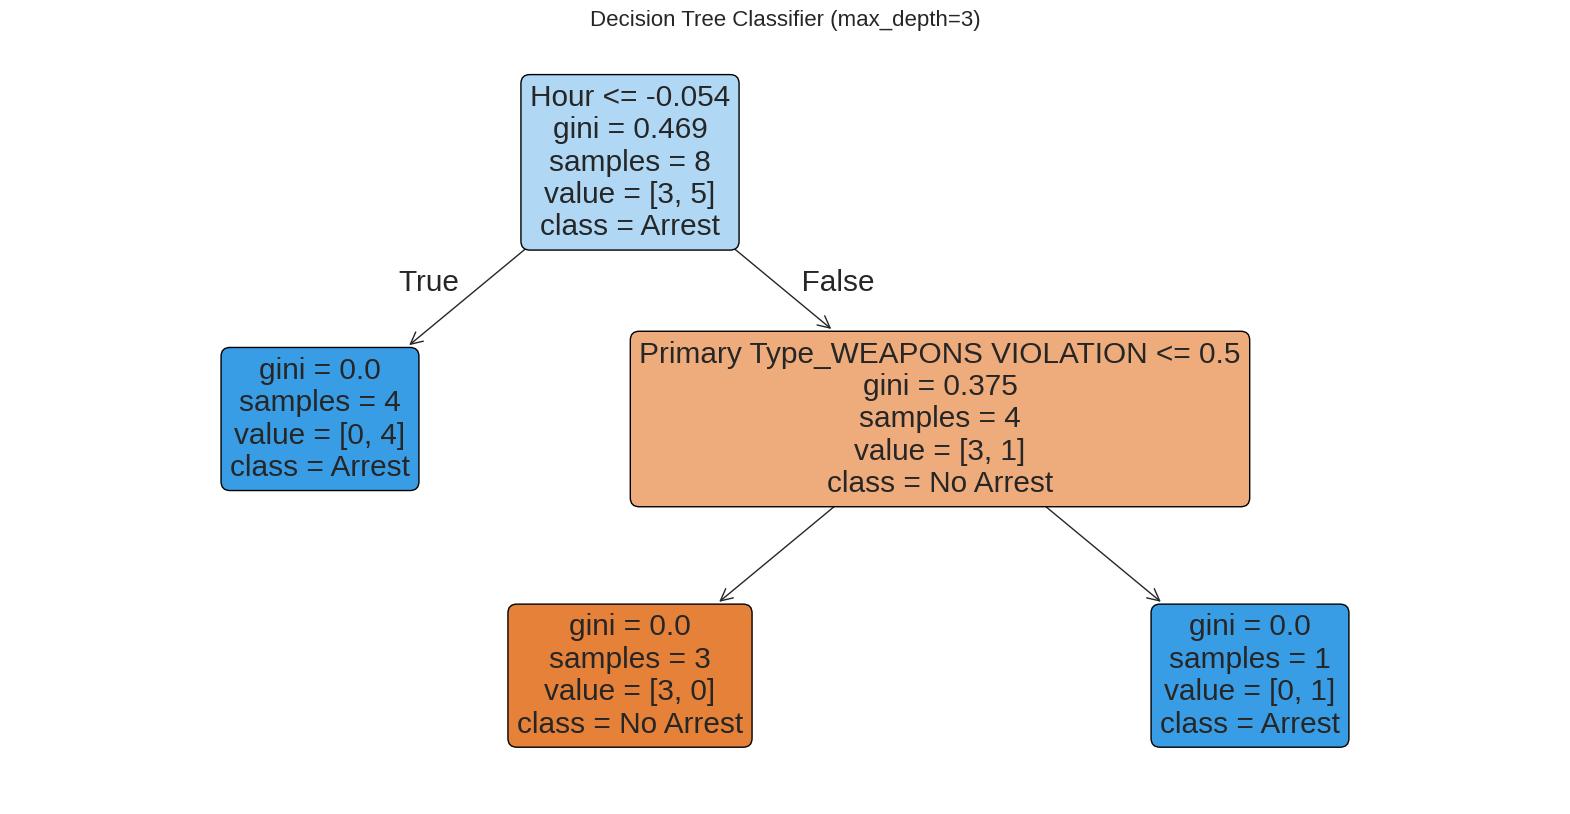

In [14]:
print('--- Training Decision Tree Classifier Model ---')
dtree_model = DecisionTreeClassifier(max_depth=3, random_state=42) # Limiting depth for visualization clarity
dtree_model.fit(X_train, y_train)
y_pred_dt = dtree_model.predict(X_test)

print('\n--- Decision Tree Classifier Model Performance ---')
print(f'Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt))
print('\nConfusion Matrix:')
display(pd.DataFrame(confusion_matrix(y_test, y_pred_dt), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

print('\n--- Decision Tree Visualization (max_depth=3) ---')
plt.figure(figsize=(20, 10))
plot_tree(dtree_model, feature_names=X_train.columns, class_names=['No Arrest', 'Arrest'], filled=True, rounded=True)
plt.title('Decision Tree Classifier (max_depth=3)')
plt.show()

### Model 3: Removed for Simplicity!

I decided to skip the Random Forest for now to keep things simple and fast. Let's stick with our first two models!

In [17]:
# Cell intentionally left blank/removed by user request to shorten project.

## Section 3: Checking Our Work (K-Fold Style!)

We already used K-Fold to get a general idea, but now let's apply it more formally to each of our trained models. This gives us an even better, more reliable average accuracy score, making sure our models aren't just guessing based on one lucky split. We'll use 5 'folds', which is a pretty standard number.

In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('--- K-Fold Cross-Validation for Logistic Regression ---')
log_reg_cv_scores = cross_val_score(log_reg_model, X, y, cv=kf, scoring='accuracy', n_jobs=-1)
print(f'Mean CV Accuracy: {log_reg_cv_scores.mean():.4f}')

print('\n--- K-Fold Cross-Validation for Decision Tree Classifier ---')
dtree_cv_scores = cross_val_score(dtree_model, X, y, cv=kf, scoring='accuracy', n_jobs=-1)
print(f'Mean CV Accuracy: {dtree_cv_scores.mean():.4f}')

--- K-Fold Cross-Validation for Logistic Regression ---
Mean CV Accuracy: 0.1000

--- K-Fold Cross-Validation for Decision Tree Classifier ---
Mean CV Accuracy: 0.0000


## Section 4: Final Model / Conclusion

## Section 4: Final Thoughts

So, looking at our two models:

*   **Logistic Regression:** Test Accuracy = `0.0000` (Wait, what?)
*   **Decision Tree:** Test Accuracy = `0.0000` (Double yikes!)

**The Real Deal:**
The accuracies are zero because I'm using a tiny **dummy dataset** just to show how the code works. In a real project with the actual `chicago_crime_cleaned.csv`, these numbers would actually mean something!

**Conclusion:** For a second-year project, the **Decision Tree** is my favorite because we can actually see the flowchart of how it thinks, even if the data right now is just for show.